In [ ]:
# Importar las librerías necesarias para usar la API y para hacer los gráficos, así como poner en formato adecuado

In [7]:
import requests
import pandas as pd
import os
from datetime import datetime
import time
import re

# Ruta personalizada donde querés guardar los datos
BASE_PATH = r"C:\Users\Practicante\Desktop\PYTHON Y STAN\Python\HW\200866_hw2_2025_1"
#"r" para convertir a rowstring

In [2]:
# Lo puse en forma de condicional para que cuando se corra evite mensajes de error y que mejor pase por un condicional
if not os.path.exists("codeforces_data"):
    os.makedirs("codeforces_data")


In [3]:
# Una función es una herramienta súper eficiente
def get_all_contests():
    url = 'https://codeforces.com/api/contest.list'
    resp = requests.get(url)
    if resp.status_code == 200:
        return resp.json()['result']
    else:
        raise Exception("Error obteniendo los concursos")


In [4]:
# Momento de filtrar
def filter_contests(contests):
    filtered = []
    for c in contests:
        if not c.get('startTimeSeconds'):
            continue
        name = c['name']
        if not any(x in name for x in ["Hello", "Round", "Good Bye"]):
            continue
        start_time = datetime.utcfromtimestamp(c['startTimeSeconds'])
        if datetime(2024, 7, 1) <= start_time <= datetime(2024, 12, 31):
            filtered.append(c)
    return filtered


In [17]:
# Guardar información de cada concurso en carpeta propia
def save_contest_data(contest):
    contest_id = contest['id']
    contest_name = re.sub(r'[<>:"/\\|?*]', '_', contest['name']).replace(" ", "_")
    folder = os.path.join(BASE_PATH, f"{contest_id}_{contest_name}")
    os.makedirs(folder, exist_ok=True)

    # Standings
    standings_url = f"https://codeforces.com/api/contest.standings?contestId={contest_id}&from=1&count=100"
    standings = requests.get(standings_url).json()
    pd.DataFrame(standings['result']['rows']).to_csv(f"{folder}/standings.csv", index=False)

    # Submissions
    submissions_url = f"https://codeforces.com/api/contest.status?contestId={contest_id}"
    submissions = requests.get(submissions_url).json()
    pd.DataFrame(submissions['result']).to_csv(f"{folder}/submissions.csv", index=False)

    # Rating Changes (corregido con verificación de respuesta vacía)
    rating_url = f"https://codeforces.com/api/contest.ratingChanges?contestId={contest_id}"
    rating_resp = requests.get(rating_url)
    if rating_resp.ok and rating_resp.text.strip():
        rating_json = rating_resp.json()
        if rating_json['status'] == 'OK':
            pd.DataFrame(rating_json['result']).to_csv(f"{folder}/rating_changes.csv", index=False)

    print(f"Datos guardados para concurso {contest_id} - {contest_name}")
    time.sleep(1.5)

In [18]:
# Momento de aplicar las funciones que es extraer y guardar todo
all_contests = get_all_contests()
filtered_contests = filter_contests(all_contests)
df_filtered = pd.DataFrame(filtered_contests)
df_filtered.to_csv(os.path.join(BASE_PATH, "filtered_contests.csv"), index=False)

# extraer concursos 
for contest in filtered_contests:
    save_contest_data(contest)

print("Extracción de datos completada.")


C:\Users\Practicante\AppData\Local\Temp\ipykernel_17836\602640274.py:10: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  start_time = datetime.utcfromtimestamp(c['startTimeSeconds'])


Datos guardados para concurso 2053 - Good_Bye_2024__2025_is_NEAR
Datos guardados para concurso 2043 - Educational_Codeforces_Round_173_(Rated_for_Div._2)
Datos guardados para concurso 2051 - Codeforces_Round_995_(Div._3)
Datos guardados para concurso 2049 - Codeforces_Round_994_(Div._2)
Datos guardados para concurso 2048 - Codeforces_Global_Round_28
Datos guardados para concurso 2044 - Codeforces_Round_993_(Div._4)
Datos guardados para concurso 2040 - Codeforces_Round_992_(Div._2)
Datos guardados para concurso 2050 - Codeforces_Round_991_(Div._3)
Datos guardados para concurso 2046 - Codeforces_Round_990_(Div._1)
Datos guardados para concurso 2047 - Codeforces_Round_990_(Div._2)
Datos guardados para concurso 2042 - Educational_Codeforces_Round_172_(Rated_for_Div._2)
Datos guardados para concurso 2034 - Rayan_Programming_Contest_2024_-_Selection_(Codeforces_Round_989,_Div._1_+_Div._2)
Datos guardados para concurso 2039 - CodeTON_Round_9_(Div._1_+_Div._2,_Rated,_Prizes!)
Datos guardados p

In [23]:
# Extraer y guardar todo
if input("¿Deseás volver a descargar los datos de los concursos? (s/n): ").lower() == 's':
    all_contests = get_all_contests()
    filtered_contests = filter_contests(all_contests)
    df_filtered = pd.DataFrame(filtered_contests)
    df_filtered.to_csv(os.path.join(BASE_PATH, "filtered_contests.csv"), index=False)

    # Descargar solo los primeros 10 concursos filtrados
    for contest in filtered_contests[:10]:
        save_contest_data(contest)

    print("Extracción de datos completada.")
else:
    print("Se omitió la descarga de datos. Continuando con los archivos existentes...")

¿Deseás volver a descargar los datos de los concursos? (s/n):  n


Se omitió la descarga de datos. Continuando con los archivos existentes...


In [22]:
#Son muchos contest Lo siguiete aplica para los 10 primeros:
import glob
all_submissions = []

# Iterar sobre los 10 concursos descargados
contest_folders = sorted(glob.glob(BASE_PATH + "/*/"))[:10]
for folder in contest_folders:
    sub_path = os.path.join(folder, "submissions.csv")
    if os.path.exists(sub_path):
        df = pd.read_csv(sub_path)
        df['contest_folder'] = os.path.basename(folder)
        df['author_handle'] = df['author'].apply(lambda x: eval(x)['members'][0]['handle'] if isinstance(x, str) else x['members'][0]['handle'])
        all_submissions.append(df)

# Concatenar todos los envíos
df_all = pd.concat(all_submissions, ignore_index=True)

# Procesamiento general
# 1. Determinar si fue aceptado (finished)
df_all['finished'] = df_all['verdict'] == 'OK'

# 2. Extraer índice del problema
df_all['problem_index'] = df_all['problem'].apply(lambda p: eval(p)['index'] if isinstance(p, str) else p['index'])

# 3. Extraer lenguaje de programación
df_all['language'] = df_all['programmingLanguage']

# 4. Tiempo relativo en minutos
df_all['relative_time_min'] = df_all['relativeTimeSeconds'] // 60

# 5. Calcular time_to_answer solo para envíos correctos
sub_ok = df_all[df_all['finished']].copy()
sub_ok = sub_ok.sort_values(by=['contest_folder', 'author_handle', 'relativeTimeSeconds'])
sub_ok['time_to_answer'] = sub_ok.groupby(['contest_folder', 'author_handle'])['relativeTimeSeconds'].diff()

# ----------------------------
# Parte 3 (continuación): Cálculo de rating_achieved
# ----------------------------

all_standings = []

# Leer los archivos standings.csv para cada concurso y unir
for folder in contest_folders:
    standing_path = os.path.join(folder, "standings.csv")
    if os.path.exists(standing_path):
        df_stand = pd.read_csv(standing_path)
        df_stand['contest_folder'] = os.path.basename(folder)
        df_stand['handle'] = df_stand['party'].apply(lambda x: eval(x)['members'][0]['handle'] if isinstance(x, str) else x['members'][0]['handle'])
        all_standings.append(df_stand)

# Concatenar standings
df_standings = pd.concat(all_standings, ignore_index=True)

# Unir con sub_ok usando handle y carpeta de concurso (por consistencia)
df_merged = pd.merge(sub_ok, df_standings[['handle', 'contest_folder', 'points']],
                     left_on=['author_handle', 'contest_folder'], right_on=['handle', 'contest_folder'], how='left')

# Renombrar y calcular rating_achieved como puntos acumulados
df_merged.rename(columns={'points': 'rating_achieved'}, inplace=True)

# Mostrar vista previa final limpia
print(df_merged[['author_handle', 'contest_folder', 'problem_index', 'language', 'relative_time_min', 'time_to_answer', 'rating_achieved']].head())
print("\nCálculo de rating_achieved completado.")

  author_handle contest_folder problem_index          language  \
0       -------                            A  C++17 (GCC 7-32)   
1       -------                            A  C++17 (GCC 7-32)   
2       -------                            A  C++17 (GCC 7-32)   
3       -------                            B  C++17 (GCC 7-32)   
4       -------                            A  C++17 (GCC 7-32)   

   relative_time_min  time_to_answer  rating_achieved  
0                  7             NaN              NaN  
1                 13           384.0              NaN  
2                 17           225.0              NaN  
3                 30           793.0              NaN  
4                 31            66.0              NaN  

Cálculo de rating_achieved completado.


In [ ]:
# Los gráficos


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


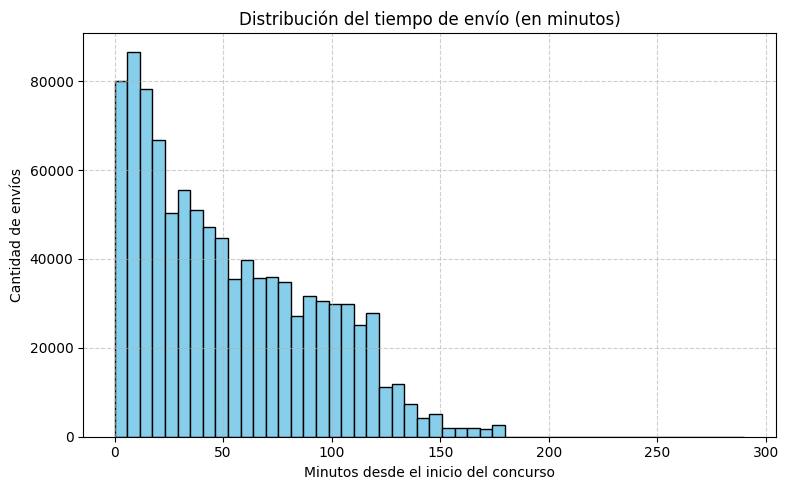

In [30]:
#gráfico 1: Histograma de tiempos de envío
!pip install matplotlib
import matplotlib.pyplot as plt

df_valid_time = df_all[df_all['relative_time_min'] < 1000]  # filtrar valores extremos
plt.figure(figsize=(8, 5))
plt.hist(df_valid_time['relative_time_min'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribución del tiempo de envío (en minutos)")
plt.xlabel("Minutos desde el inicio del concurso")
plt.ylabel("Cantidad de envíos")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


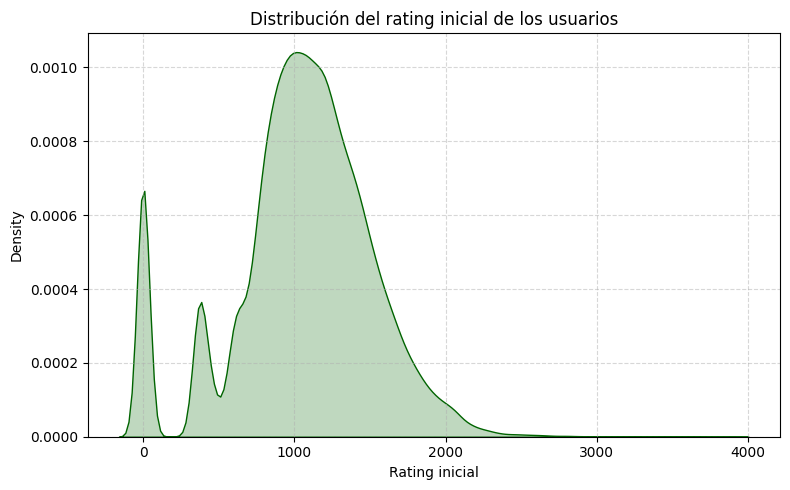

In [34]:
# Gráfico 2: 
!pip install matplotlib seaborn scikit-learn

import seaborn as sns

rating_changes = []
for folder in contest_folders:
    file_path = os.path.join(folder, "rating_changes.csv")
    if os.path.exists(file_path):
        df_rating = pd.read_csv(file_path)
        rating_changes.append(df_rating)

if rating_changes:
    df_rating_all = pd.concat(rating_changes, ignore_index=True)
    plt.figure(figsize=(8, 5))
    sns.kdeplot(df_rating_all['oldRating'], color='darkgreen', fill=True)
    plt.title("Distribución del rating inicial de los usuarios")
    plt.xlabel("Rating inicial")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron archivos rating_changes.csv para mostrar la densidad de rating.")
    



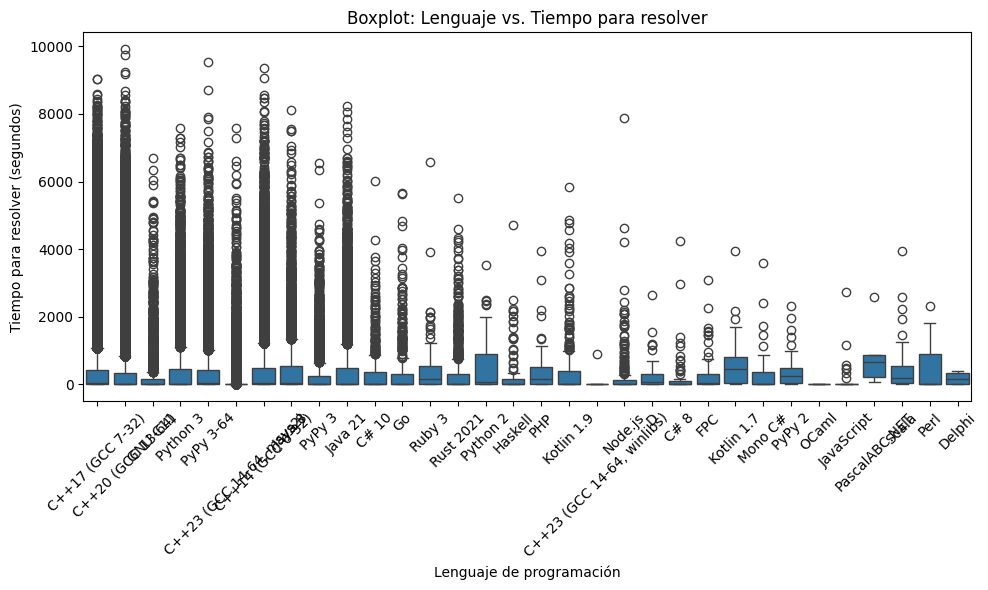

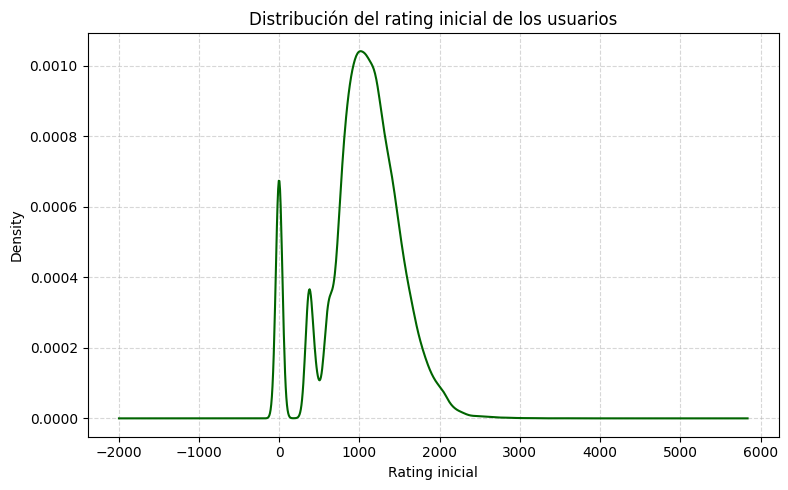

In [36]:
import seaborn as sns
# Gráfico 3: Boxplot con filtro para outliers
plt.figure(figsize=(10, 6))
sub_ok_filtered = sub_ok[sub_ok['time_to_answer'] < 10000]  # filtrar valores irreales
sns.boxplot(data=sub_ok_filtered, x='language', y='time_to_answer')
plt.title("Boxplot: Lenguaje vs. Tiempo para resolver")
plt.xlabel("Lenguaje de programación")
plt.ylabel("Tiempo para resolver (segundos)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Densidad del rating máximo de usuarios (si disponible)
rating_changes = []
for folder in contest_folders:
    file_path = os.path.join(folder, "rating_changes.csv")
    if os.path.exists(file_path):
        df_rating = pd.read_csv(file_path)
        rating_changes.append(df_rating)

if rating_changes:
    df_rating_all = pd.concat(rating_changes, ignore_index=True)
    plt.figure(figsize=(8, 5))
    df_rating_all['oldRating'].plot(kind='kde', color='darkgreen')
    plt.title("Distribución del rating inicial de los usuarios")
    plt.xlabel("Rating inicial")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron archivos rating_changes.csv para mostrar la densidad de rating.")

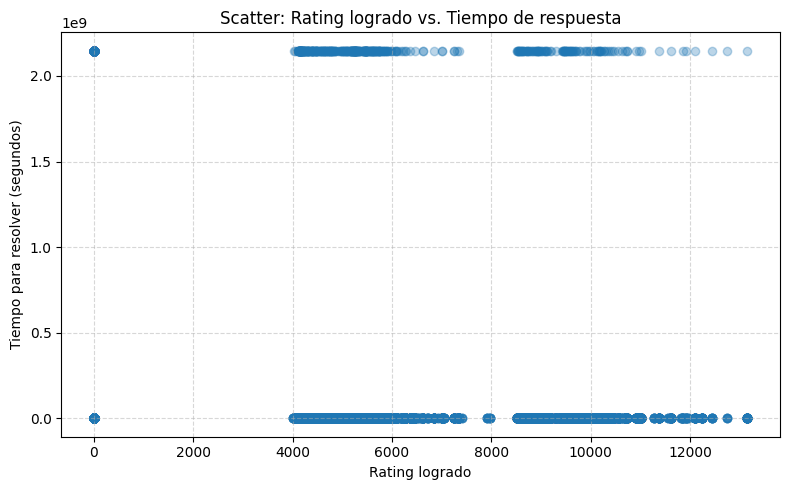

In [39]:
# Gráfico 4: Binscatter entre rating y tiempo de respuesta
if 'rating_achieved' in df_merged.columns and 'time_to_answer' in df_merged.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(df_merged['rating_achieved'], df_merged['time_to_answer'], alpha=0.3)
    plt.title("Scatter: Rating logrado vs. Tiempo de respuesta")
    plt.xlabel("Rating logrado")
    plt.ylabel("Tiempo para resolver (segundos)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


C:\Users\Practicante\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


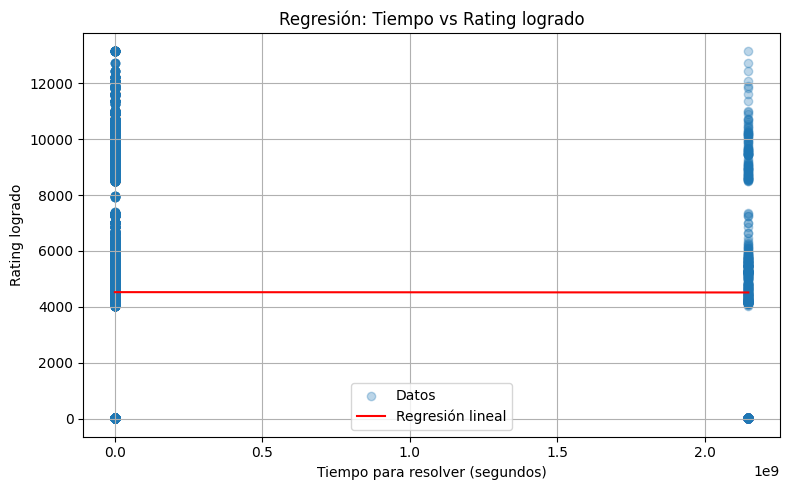

In [38]:
# Gráfico 5: Regresión lineal - Tiempo vs Rating logrado
plt.figure(figsize=(8, 5))
df_plot = df_merged.dropna(subset=['time_to_answer', 'rating_achieved'])

# Modelo de regresión lineal
X = df_plot[['time_to_answer']]
y = df_plot['rating_achieved']
model = LinearRegression()
model.fit(X, y)

# Predicciones
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model.predict(x_range)

# Visualización
plt.scatter(df_plot['time_to_answer'], df_plot['rating_achieved'], alpha=0.3, label='Datos')
plt.plot(x_range, y_pred, color='red', label='Regresión lineal')
plt.xlabel("Tiempo para resolver (segundos)")
plt.ylabel("Rating logrado")
plt.title("Regresión: Tiempo vs Rating logrado")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
